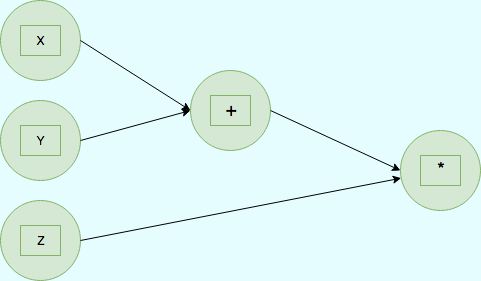

## Implement a Computational Graph Node Class

**Goal:** Implement a `Node` class to represent values in a computational graph, supporting element-wise arithmetic operations and tracking dependencies for automatic differentiation.

### Task Breakdown:

1.  **Define the `Node` class:**
    *   **Attributes:**
        *   `value`: Stores the numerical value (NumPy array).
        *   `children`: Tracks dependencies (other `Node` objects used to compute the current node).
        *   `op`: Stores the operation that created the node (e.g., "add", "mul").
        *   `op_args`: Stores additional operation-related constants if needed.

2.  **Overload Arithmetic Operators:**
    *   Support element-wise operations between `Node` objects and constants for:
        *   Addition (+)
        *   Subtraction (-)
        *   Multiplication (*)
        *   Division (/)
        *   Exponentiation (**)

3.  **Track Dependencies in the Computation Graph:**
    *   If an operation involves two `Node` objects, store both as `children`.
    *   If an operation involves a constant, store only the `Node` operand.
    *   *Example:* For `a = (x+y)*z`, let `b = x+y`.
        *   `b` and `z` are `children` of `a`.
        *   `x` and `y` are `children` of `b`.

4.  **Implement `backward()` method for gradient computation:**
    *   **Purpose:** Compute gradients using the chain rule, propagating them correctly through the computation graph from the output node to its dependencies.
    *   **Initialization:** Initialize `grad` to 1 if the node is the starting Node of backpropagation.
    *   **Propagation:** Propagate gradients recursively to all dependent nodes (`children`) based on the operation performed.

5.  **Implement Gradient Calculations for Operations:**
    *   **Addition (+):** Gradient is passed unchanged to both operands.
    *   **Subtraction (-):** Left operand receives `grad`, right operand receives `-grad`.
    *   **Multiplication (*):** Uses the product rule.
    *   **Division (/):** Uses the quotient rule.
    *   **Exponentiation (**):** Uses the power rule and logarithm differentiation.

6.  **Perform Backpropagation:**
    *   Compute gradients by calling `backward()` from the final output node.
    *   Ensure gradients accumulate correctly when a node is used in multiple operations.

7.  **Verify Correctness (Example):**
    *   Create two `Node` objects (e.g., `a` and `b`) initialized with NumPy arrays.
    *   Compute intermediate and final results:
        *   `c = a × 2 + b`
        *   `d = c^3`
    *   Call `d.backward()` to compute the gradient of `d` with respect to `a`, `b`, and `c`.
    *   Print the computed gradients.

In [5]:
import numpy as np

In [16]:
class Node:
    def __init__(self,value,children=None,op=None,grad=None):
        self.value=np.array(value)
        self.children = children if children else []
        self.op=op
        self.grad=np.zeros_like(self.value)
    def __add__(self,other):return self._add(other)
    def __sub__(self,other):return self._sub(other)
    def __mul__(self,other):return self._mul(other)
    def __truediv__(self,other):return self._div(other)
    def __pow__(self,other):return self._exp(other)
    def __radd__(self, other): return self._add(other)
    def __rsub__(self, other): return Node(other)._sub(self)
    def __rmul__(self, other): return self._mul(other)
    def __rtruediv__(self, other): return Node(other)._div(self)
    
    def _add(self,x):
        x = x if isinstance(x,Node) else Node(x)
        return Node(self.value+x.value,children=[self,x],op='add')
    def _sub(self,x):
        x = x if isinstance(x,Node) else Node(x)
        return Node(self.value-x.value,children=[self,x],op='sub')
    def _mul(self,x):
        x = x if isinstance(x,Node) else Node(x)
        return Node(self.value*x.value,children=[self,x],op='mul')
    def _div(self,x):
        x = x if isinstance(x,Node) else Node(x)
        return Node(self.value/x.value,children=[self,x],op='div')
    def _exp(self,x):
        x = x if isinstance(x,Node) else Node(x)
        return Node(self.value**x.value,children=[self,x],op='exp')
    
    def backward(self,root=True):
        if root:
            self.grad=np.ones_like(self.value)
        op = self.op
        if op=='add':
            c1,c2 = self.children
            c1.grad += self.grad
            c2.grad += self.grad
        elif op=='sub':
            c1,c2 = self.children
            c1.grad += self.grad
            c2.grad -= self.grad
        elif op=='mul':
            c1,c2 = self.children
            c1.grad += c2.value * self.grad
            c2.grad += c1.value * self.grad
        elif op=='div':
            c1,c2 = self.children
            c1.grad += (1 / c2.value) * self.grad
            c2.grad += (-c1.value / (c2.value**2)) * self.grad
        elif op=='exp':
            c1,c2 = self.children
            c1.grad += c2.value * (c1.value ** (c2.value - 1)) * self.grad
            c2.grad += (self.value * np.log(c1.value)) * self.grad
            
        for c in self.children:
            c.backward(root=False)

In [18]:
a = Node([2.0])
b = Node([3.0])
two = Node([2.0])
three = Node([3.0])
c = (a._mul(two))._add(b)
d=c._exp(three)
d.backward()
print(f"A Gradient : {a.grad}")
print(f"B Gradient : {b.grad}")

A Gradient : [294.]
B Gradient : [147.]
